# 10: Automated Mask Generation from Eye Tracking

This notebook implements a fully automated pipeline for generating SAM2 segmentation masks from Project Aria eye-tracking data. Instead of manually selecting frames and drawing bounding boxes as prompts, we use the gaze signal recorded by the Aria glasses to automatically identify which objects the wearer is looking at.

### In this notebook, we will:
1. **Recording setup**: Configure paths for the VRS recording and its MPS outputs.
2. **Gaze loading & alignment**: Load the MPS eye-gaze stream and align it temporally with the RGB frames.
3. **Gaze projection**: Convert the raw gaze direction into a 2D pixel coordinate on the RGB image plane.
4. **Fixation detection**: Apply a dispersion-based fixation detector (I-DT) to identify sustained gaze episodes that indicate intentional object observation.
5. **SAM2 prompt generation**: Use each fixation centroid as a point prompt for SAM2, with deduplication to avoid re-segmenting already-masked objects.
6. **Mask export & validation**: Save the generated masks with diagnostic overlays.
7. **Conclusions & handoff**: Summary of detected objects and readiness for the NeRF reconstruction pipeline.

**Note**:  The Aria ET camera operates at ~10 fps while the RGB camera runs at 30 fps. The MPS eye-gaze output inherits the ET rate, so temporal alignment is required before any gaze-to-image projection.

As a sample, we will use the `office_cabinet.vrs` and `table_objects.vrs` recordings. The table_objects recording will be downsaplet to 5 FPS.

## 10.1 Recording Configuration & Setup

Configure all input/output paths for the target recording.

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from PIL import Image
from projectaria_tools.core import data_provider, mps

RECORDING_NAME = "table_objects"

# input paths
DATA_ROOT = os.path.join("..", "data", "raw", RECORDING_NAME)
VRS_PATH = os.path.join(DATA_ROOT, f"{RECORDING_NAME}.vrs")
MPS_ROOT = os.path.join(DATA_ROOT, f"mps_{RECORDING_NAME}_vrs")
SLAM_DIR = os.path.join(MPS_ROOT, "slam")
GAZE_DIR = os.path.join(MPS_ROOT, "eye_gaze")
GAZE_CSV = os.path.join(GAZE_DIR, "general_eye_gaze.csv")

# output paths
OUT_ROOT = os.path.join("..", "data", "outputs", "segmentation", RECORDING_NAME)
FRAMES_DIR = os.path.join(OUT_ROOT, "frames_5fps")
MASKS_DIR = os.path.join(OUT_ROOT, "sam2", "masks")

for d in [FRAMES_DIR, MASKS_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"Recording: {RECORDING_NAME}")
print(f"VRS: {os.path.abspath(VRS_PATH)}")
print(f"Gaze CSV: {GAZE_CSV}")
print(f"MPS root: {os.path.abspath(MPS_ROOT)}")
print(f"Output: {os.path.abspath(OUT_ROOT)}")

Recording: table_objects
VRS: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\table_objects\table_objects.vrs
Gaze CSV: ..\data\raw\table_objects\mps_table_objects_vrs\eye_gaze\general_eye_gaze.csv
MPS root: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\raw\table_objects\mps_table_objects_vrs
Output: c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\data\outputs\segmentation\table_objects


### 10.1.2 VRS Access & RGB Stream Resolution

Open the VRS file, resolve the RGB stream, and read its metadata. This validates that the recording is decodable and provides the frame count and resolution needed for downstream extraction.

In [2]:
# Open VRS and resolve RGB stream

provider = data_provider.create_vrs_data_provider(VRS_PATH)

rgb_stream_id = provider.get_stream_id_from_label("camera-rgb")
rgb_config    = provider.get_image_configuration(rgb_stream_id)
n_rgb_total   = provider.get_num_data(rgb_stream_id)

IMG_W = rgb_config.image_width
IMG_H = rgb_config.image_height

print(f"RGB stream ID: {rgb_stream_id}")
print(f"RGB frames: {n_rgb_total}")
print(f"Resolution: {IMG_W}x{IMG_H}")

RGB stream ID: 214-1
RGB frames: 2764
Resolution: 1408x1408


### 10.1.3 RGB Frame Extraction at 5 fps

The native RGB stream runs at 30 fps. We subsample every 6th frame to produce a 5 fps sequence. This reduces the total frame count for long recordings while still providing sufficient temporal resolution for fixation detection and SAM2 propagation.

In [3]:
# Helper to extract image array from a projectaria_tools sensor sample

from operator import index

from matplotlib.pylab import sample


def extract_rgb_frame(provider, stream_id, index):
    """Read one RGB frame from the VRS by index, return as HxWx3 numpy array."""
    sample = provider.get_sensor_data_by_index(stream_id, index)

# Navigate the accessor hierarchy
    for attr in ["image_data_and_record", "image_data", "image"]:
        if not hasattr(sample, attr):
            continue
        payload = getattr(sample, attr)
        payload = payload() if callable(payload) else payload

        # Handle (ImageData, record) tuples
        if isinstance(payload, tuple):
            payload = payload[0]

        # Try .to_numpy_array()
        for arr_attr in ["to_numpy_array", "buffer"]:
            if hasattr(payload, arr_attr):
                arr = getattr(payload, arr_attr)
                arr = arr() if callable(arr) else arr
                arr = np.asarray(arr)
                if arr.ndim >= 2:
                    # Channel-first to channel-last
                    if arr.ndim == 3 and arr.shape[0] in (1, 3) and arr.shape[-1] not in (1, 3):
                        arr = np.transpose(arr, (1, 2, 0))
                    return arr.astype(np.uint8)

    raise RuntimeError(f"Cannot extract image from sample at index {index}")


# Validate extraction on a single frame
test_frame = extract_rgb_frame(provider, rgb_stream_id, 0)
print(f"Frame extraction OK: shape={test_frame.shape}, dtype={test_frame.dtype}")

Frame extraction OK: shape=(1408, 1408, 3), dtype=uint8


In [ ]:
# convert to 5 FPS
SUBSAMPLE_STRIDE = 6  # 30 fps / 6 = 5 fps

indices_5fps = list(range(0, n_rgb_total, SUBSAMPLE_STRIDE))
n_frames_5fps = len(indices_5fps)

print(f"Subsampling: stride={SUBSAMPLE_STRIDE} -> {n_frames_5fps} frames at 5 fps")

existing = len([f for f in os.listdir(FRAMES_DIR) if f.endswith(".jpg")])
if existing >= n_frames_5fps:
    print(f"Frames already extracted ({existing} files), skipping.")
else:
    for out_idx, vrs_idx in enumerate(indices_5fps):
        frame = extract_rgb_frame(provider, rgb_stream_id, vrs_idx)
        pil_img = Image.fromarray(frame)
        out_path = os.path.join(FRAMES_DIR, f"{out_idx:06d}.jpg")
        pil_img.save(out_path, quality=95)
        if (out_idx + 1) % 50 == 0:
            print(f"  [{out_idx+1}/{n_frames_5fps}] saved")

    print(f"[OK] {n_frames_5fps} frames saved to: {FRAMES_DIR}")

Subsampling: stride=6 -> 461 frames at 5 fps
  [50/461] saved
  [100/461] saved
  [150/461] saved
  [200/461] saved
  [250/461] saved
  [300/461] saved
  [350/461] saved
  [400/461] saved
  [450/461] saved
[OK] 461 frames saved to: ..\data\outputs\segmentation\table_objects\frames_5fps


In [5]:
# Build timestamp arrays for both the full 30fps stream and the 5fps subset

from projectaria_tools.core.sensor_data import TimeDomain

rgb_timestamps_ns_30fps = np.array([
                        provider.get_sensor_data_by_index(rgb_stream_id, i).get_time_ns(TimeDomain.DEVICE_TIME)
                        for i in range(n_rgb_total)], dtype=np.int64)

# 5fps subset timestamps
rgb_timestamps_ns = rgb_timestamps_ns_30fps[indices_5fps]

rgb_duration_s = (rgb_timestamps_ns[-1] - rgb_timestamps_ns[0]) / 1e9
rgb_rate_hz = len(rgb_timestamps_ns) / rgb_duration_s

print(f"5fps frames: {len(rgb_timestamps_ns)}")
print(f"Duration: {rgb_duration_s:.2f} s")
print(f"Measured rate: {rgb_rate_hz:.2f} Hz")

5fps frames: 461
Duration: 91.99 s
Measured rate: 5.01 Hz


## 10.2 Eye Gaze Loading & Temporal Alignment

Load the MPS eye-gaze stream and align it with the extracted 10 fps RGB frames. The gaze data is sampled by the ET cameras at a rate distinct from the RGB camera. For each 10 fps frame, we find the temporally closest gaze sample via searchsorted and flag matches that exceed a configurable time-delta threshold.

In [7]:
# Load eye-gaze samples via the MPS API

eye_gazes = mps.read_eyegaze(GAZE_CSV)
n_gaze = len(eye_gazes)

if n_gaze == 0:
    raise ValueError("Eye-gaze CSV is empty, check MPS processing.")

print(f"Gaze samples loaded: {n_gaze}")

# Inspect available fields on the first sample for debugging

sample_fields = [a for a in dir(eye_gazes[0]) if not a.startswith("_")]
print(f"Sample fields: {sample_fields}")

Gaze samples loaded: 921
Sample fields: ['depth', 'pitch', 'pitch_high', 'pitch_low', 'session_uid', 'tracking_timestamp', 'vergence', 'yaw', 'yaw_high', 'yaw_low']


In [8]:
#Extract gaze timestamps in nanoseconds
# The exact accessor varies by projectaria_tools version

g0 = eye_gazes[0]

if hasattr(g0, "tracking_timestamp") and hasattr(g0.tracking_timestamp, "total_seconds"):
    # timedelta object
    gaze_timestamps_ns = np.array([int(g.tracking_timestamp.total_seconds() * 1e9) for g in eye_gazes], dtype=np.int64)
    print("Timestamp accessor: tracking_timestamp.total_seconds()")

elif hasattr(g0, "tracking_timestamp_us"):
    # integer microseconds
    gaze_timestamps_ns = np.array([g.tracking_timestamp_us * 1000 for g in eye_gazes], dtype=np.int64)
    print("Timestamp accessor: tracking_timestamp_us")

else:
    raise AttributeError(f"Cannot determine timestamp field. Available: {sample_fields}")

gaze_duration_s = (gaze_timestamps_ns[-1] - gaze_timestamps_ns[0]) / 1e9
gaze_rate_hz = n_gaze / gaze_duration_s

print(f"Gaze duration: {gaze_duration_s:.2f} s")
print(f"Gaze rate: {gaze_rate_hz:.2f} Hz")
print(f"Rate mismatch: RGB {rgb_rate_hz:.1f} Hz vs Gaze {gaze_rate_hz:.1f} Hz")

Timestamp accessor: tracking_timestamp.total_seconds()
Gaze duration: 91.99 s
Gaze rate: 10.01 Hz
Rate mismatch: RGB 5.0 Hz vs Gaze 10.0 Hz


In [9]:
# Extract yaw and pitch fields (CPF = Central Pupil Frame)

g0 = eye_gazes[0]

if hasattr(g0, "yaw"):
    get_yaw   = lambda g: g.yaw
    get_pitch = lambda g: g.pitch
    print("Gaze direction fields: yaw, pitch")
elif hasattr(g0, "yaw_rads_cpf"):
    get_yaw   = lambda g: g.yaw_rads_cpf
    get_pitch = lambda g: g.pitch_rads_cpf
    print("Gaze direction fields: yaw_rads_cpf, pitch_rads_cpf")
else:
    raise AttributeError(f"Cannot find yaw/pitch fields. Available: {sample_fields}")

# Sanity check on gaze range
yaw_all   = np.array([get_yaw(g) for g in eye_gazes])
pitch_all = np.array([get_pitch(g) for g in eye_gazes])

print(f"Yaw range: [{np.degrees(yaw_all.min()):.1f}, {np.degrees(yaw_all.max()):.1f}] deg")
print(f"Pitch range: [{np.degrees(pitch_all.min()):.1f}, {np.degrees(pitch_all.max()):.1f}] deg")

Gaze direction fields: yaw, pitch
Yaw range: [-17.3, 19.4] deg
Pitch range: [-43.7, 19.0] deg


In [10]:
# Temporal alignment, for each 10fps RGB frame, find the nearest gaze sample.

MAX_DELTA_MS = 60.0 # half the gaze interval at 10 fps

# Nearest-neighbour matching via binary search

insert_pos = np.searchsorted(gaze_timestamps_ns, rgb_timestamps_ns)
insert_pos = np.clip(insert_pos, 1, n_gaze - 1)

delta_before = np.abs(rgb_timestamps_ns - gaze_timestamps_ns[insert_pos - 1])
delta_after  = np.abs(rgb_timestamps_ns - gaze_timestamps_ns[insert_pos])

nearest_gaze_idx = np.where(delta_before < delta_after, insert_pos - 1, insert_pos)
nearest_delta_ms = np.minimum(delta_before, delta_after) / 1e6

reliable = nearest_delta_ms < MAX_DELTA_MS

print(f"Frames aligned: {len(rgb_timestamps_ns)}")
print(f"Reliable: {reliable.sum()} ({100*reliable.mean():.1f}%)")
print(f"Median delta: {np.median(nearest_delta_ms):.2f} ms")
print(f"Max delta: {nearest_delta_ms.max():.2f} ms")
print(f"Unreliable: {(~reliable).sum()}")

Frames aligned: 461
Reliable: 460 (99.8%)
Median delta: 33.23 ms
Max delta: 66.76 ms
Unreliable: 1


In [11]:
# Build the final alignment table: one row per 10fps frame

alignment = pd.DataFrame({
"frame_idx":     np.arange(len(rgb_timestamps_ns)),
"rgb_ts_ns":     rgb_timestamps_ns,
"gaze_idx":      nearest_gaze_idx,
"gaze_ts_ns":    gaze_timestamps_ns[nearest_gaze_idx],
"delta_ms":      nearest_delta_ms,
"reliable":      reliable,
"yaw_rads":      [get_yaw(eye_gazes[i])   for i in nearest_gaze_idx],
"pitch_rads":    [get_pitch(eye_gazes[i]) for i in nearest_gaze_idx],
})

print(alignment.head(10).to_string(index=False))
print(f"\n... ({len(alignment)} rows)")
print(f"\nAlignment table ready. {reliable.sum()}/{len(alignment)} frames have reliable gaze data.")

 frame_idx   rgb_ts_ns  gaze_idx  gaze_ts_ns  delta_ms  reliable  yaw_rads  pitch_rads
         0 32338295325         0 32405054000 66.758675     False -0.043235   -0.196103
         1 32538263525         1 32505038000 33.225525      True -0.036714   -0.194961
         2 32738259950         3 32705005999 33.253951      True -0.019117   -0.187841
         3 32938199525         5 32904974000 33.225525      True  0.063002   -0.216120
         4 33138166575         7 33104942000 33.224575      True  0.079901   -0.190325
         5 33338136200         9 33304910000 33.226200      True  0.009516   -0.376957
         6 33538105775        11 33504877999 33.227776      True -0.095966   -0.562813
         7 33738075825        13 33704846000 33.229825      True -0.043533   -0.425804
         8 33938035200        15 33904814000 33.221200      True -0.072532   -0.511752
         9 34138003950        17 34104782000 33.221950      True -0.033391   -0.472513

... (461 rows)

Alignment table ready. 460

## 10.3 Gaze Projection to 2D Image Plane

To use the eye-tracking data as prompts for SAM2, we must project the 3D gaze vector onto the 2D pixel coordinate system of the RGB camera.

The Aria gaze data is defined in the Central Pupil Frame (CPF). The mathematical transformation chain is:
`CPF Frame` to`Device Frame` to`RGB Camera Frame` to `2D Pixel Coordinates`

First, we load the specific device calibration from the VRS provider.

In [12]:
# Extract device and camera calibration
device_calib = provider.get_device_calibration()
rgb_calib = device_calib.get_camera_calib("camera-rgb")

# Extract the spatial transformations (Sophus SE3 / RigidTransform)
T_device_cpf = device_calib.get_transform_device_cpf()
T_device_rgb = rgb_calib.get_transform_device_camera()

# Invert to get Camera <- Device
T_rgb_device = T_device_rgb.inverse()

print(f"RGB Camera Intrinsics: {rgb_calib.get_model_name()}")
print(f"Calibration loaded successfully.")

RGB Camera Intrinsics: CameraModelType.FISHEYE624
Calibration loaded successfully.


### 10.3.1 Defining the Projection Logic

We define a dedicated function to perform the ray transformations. The gaze direction is represented by `yaw` and `pitch` angles. We compute the directional vector at an arbitrary depth since the 2D projection is scale-invariant.

In [13]:
def project_gaze_to_rgb(yaw_rads, pitch_rads, rgb_calib, T_device_cpf, T_rgb_device):
    # Define the 3D gaze vector in the CPF frame, assuming standard pinhole projection model for the optical ray
    gaze_vector_cpf = np.array([np.tan(yaw_rads), np.tan(pitch_rads), 1.0])

    # Transform the vector to the RGB camera coordinate system
    gaze_vector_device = T_device_cpf @ gaze_vector_cpf
    gaze_vector_rgb = T_rgb_device @ gaze_vector_device
    
    # Project to 2D pixel space
    pixel = rgb_calib.project(gaze_vector_rgb)
    
    return pixel

### 10.3.2 Applying Projection to the Aligned Dataset

We iterate over the temporally aligned gaze dataframe (`df_gaze_aligned`) to compute the 2D coordinates for each synchronized frame. We also filter out projections that fall completely outside the RGB sensor's Field of View.

In [14]:
# Initialize empty lists for coordinates
gaze_pixels_x = []
gaze_pixels_y = []
valid_flags = []

# Apply projection frame-by-frame using the alignment dataframe
for idx, row in alignment.iterrows():
    # Handle NaN values or temporally unreliable matches explicitly
    if pd.isna(row['yaw_rads']) or pd.isna(row['pitch_rads']) or not row['reliable']:
        gaze_pixels_x.append(np.nan)
        gaze_pixels_y.append(np.nan)
        valid_flags.append(False)
        continue
        
    pixel = project_gaze_to_rgb(row['yaw_rads'], row['pitch_rads'], rgb_calib, T_device_cpf, T_rgb_device)
    
    if pixel is not None:
        u, v = pixel[0], pixel[1]
        
        # FOV Boundary Check, ensures the projection lands inside the image resolution
        is_valid = (0 <= u < IMG_W) and (0 <= v < IMG_H)
        
        gaze_pixels_x.append(u)
        gaze_pixels_y.append(v)
        valid_flags.append(is_valid)
    else:
        gaze_pixels_x.append(np.nan)
        gaze_pixels_y.append(np.nan)
        valid_flags.append(False)

# Store results back into the existing alignment dataframe
alignment['gaze_x'] = gaze_pixels_x
alignment['gaze_y'] = gaze_pixels_y
alignment['valid_gaze'] = valid_flags

valid_count = alignment['valid_gaze'].sum()
total_count = len(alignment)

print(f"Projection complete. Valid in-frame gaze points: {valid_count}/{total_count}")
print(alignment[['frame_idx', 'reliable', 'gaze_x', 'gaze_y', 'valid_gaze']].head())

Projection complete. Valid in-frame gaze points: 460/461
   frame_idx  reliable      gaze_x      gaze_y  valid_gaze
0          0     False         NaN         NaN       False
1          1      True  754.094838  657.951390        True
2          2      True  749.828941  668.646093        True
3          3      True  768.076905  718.345605        True
4          4      True  752.205596  728.896342        True


## 10.4 Fixation Detection (I-DT Algorithm)

Because Raw eye-tracking data includes rapid eye movements and noise, to identify intentional object observation, we must extract **fixations**.

We implement a standard Dispersion-Threshold Identification (I-DT) algorithm. A fixation is identified only if the user's gaze remains within a limited pixel radius (`dispersion_threshold`) for a minimum amount of continuous time (`min_duration_frames`). We require ~2.0 seconds of sustained focus to trigger a valid SAM2 prompt.

In [15]:
def detect_fixations_idt(df_alignment, dispersion_threshold, min_duration_frames):
    fixations = []
    
    # Extract relevant columns as numpy arrays for efficiency
    valid_mask = df_alignment['valid_gaze'].values
    xs = df_alignment['gaze_x'].values
    ys = df_alignment['gaze_y'].values
    frames = df_alignment['frame_idx'].values
    
    n_points = len(frames)
    i = 0
    
    while i <= n_points - min_duration_frames:
        # Check if the current window of min_duration_frames is valid
        if not all(valid_mask[i : i + min_duration_frames]):
            i += 1  # Slide the window by 1 frame
            continue
            
        win_xs = xs[i : i + min_duration_frames].tolist()
        win_ys = ys[i : i + min_duration_frames].tolist()
        
        # Initial dispersion calculation for the current window
        dispersion = (max(win_xs) - min(win_xs)) + (max(win_ys) - min(win_ys))
        
        if dispersion <= dispersion_threshold:
            j = i + min_duration_frames
            
            while j < n_points and valid_mask[j]:
                win_xs.append(xs[j])
                win_ys.append(ys[j])
                
                new_dispersion = (max(win_xs) - min(win_xs)) + (max(win_ys) - min(win_ys))
                
                if new_dispersion > dispersion_threshold:
                    # If the dispersion exceeds the threshold, remove the last point and break
                    win_xs.pop()
                    win_ys.pop()
                    break
                j += 1
            
            # Save the fixation by calculating the median
            fixations.append({
                'start_frame': int(frames[i]),
                'end_frame': int(frames[j-1]),
                'centroid_x': float(np.median(win_xs)),
                'centroid_y': float(np.median(win_ys)),
                'duration_frames': j - i
            })
            
            # Skip the entire block of the fixation we just closed
            i = j
        else:
            # Move the start forward by one frame if the window is not a fixation
            i += 1 

    return fixations

### 10.4.1 Fixation Threshold Calibration

Before setting a strict threshold for SAM2, we run the I-DT algorithm with a very low minimum duration to capture almost all gaze pauses. 

We then compute the actual time in seconds for each fixation and display a sorted analytical table. This diagnostic step helps us understand the gaze distribution for this specific recording and choose the optimal `MIN_FRAMES` threshold to separate intentional observation from casual glances.

In [ ]:
# Debug configuration: catch almost everything
DEBUG_DISPERSION_PX = 85
DEBUG_MIN_FRAMES = 10

# Run extraction with low thresholds
all_fixations = detect_fixations_idt(
    alignment, 
    dispersion_threshold=DEBUG_DISPERSION_PX, 
    min_duration_frames=DEBUG_MIN_FRAMES
)

if len(all_fixations) > 0:
    df_debug = pd.DataFrame(all_fixations)
    
    # Calculate time metrics based on 5 fps extraction rate
    FPS = 5.0
    df_debug['duration_seconds'] = df_debug['duration_frames'] / FPS
    df_debug['start_sec'] = df_debug['start_frame'] / FPS
    df_debug['end_sec'] = df_debug['end_frame'] / FPS
    
    # Reorder columns for readability
    cols = ['start_frame', 'end_frame', 'start_sec', 'end_sec', 'duration_frames', 'duration_seconds', 'centroid_x', 'centroid_y']
    df_debug = df_debug[cols]
    
    # Sort by duration (longest fixations first) to easily spot intentional observations
    df_debug = df_debug.sort_values(by='duration_seconds', ascending=False).reset_index(drop=True)
    
    print(f"Debug: Found {len(df_debug)} total micro-fixations (>={DEBUG_MIN_FRAMES} frames).")
    print("-" * 50)
    print("Fixation Length Distribution (Seconds):")
    print(df_debug['duration_seconds'].describe().round(2))
    print("-" * 50)
    
    print("\nDetailed Fixation Table (Sorted by Duration):")
    display(df_debug)
else:
    print("No fixations found, even with debug thresholds. Check data integrity.")

Debug: Found 5 total micro-fixations (>=10 frames).
--------------------------------------------------
Fixation Length Distribution (Seconds):
count    5.00
mean     2.68
std      0.84
min      2.00
25%      2.00
50%      2.40
75%      3.00
max      4.00
Name: duration_seconds, dtype: float64
--------------------------------------------------

Detailed Fixation Table (Sorted by Duration):


,start_frame,end_frame,start_sec,end_sec,duration_frames,duration_seconds,centroid_x,centroid_y
0,384,403,76.8,80.6,20,4.0,729.258186,701.507366
1,363,377,72.6,75.4,15,3.0,781.861477,700.088725
2,84,95,16.8,19.0,12,2.4,768.416713,712.421157
3,173,182,34.6,36.4,10,2.0,793.226122,713.092739
4,274,283,54.8,56.6,10,2.0,625.135445,681.834480


### 10.4.2 Visual Verification of Detected Fixations

To ensure our algorithm correctly identifies intentional observations, we visualize the target objects. 

In [43]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
from PIL import Image

def visualize_fixation(fixation_row, frames_dir, dispersion_radius=60, figsize=(6, 6)):
    # Find the median frame of the fixation temporal window
    start_f = int(fixation_row['start_frame'])
    end_f = int(fixation_row['end_frame'])
    mid_frame = int((start_f + end_f) / 2)
    
    img_path = os.path.join(frames_dir, f"{mid_frame:06d}.jpg")
    
    if not os.path.exists(img_path):
        print(f"Error: Frame {img_path} not found on disk.")
        return
        
    img = Image.open(img_path)
    cx = fixation_row['centroid_x']
    cy = fixation_row['centroid_y']
    duration_s = fixation_row['duration_seconds']
    
    # Setup the plot with the smaller figsize
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    
    # Draw crosshair at centroid
    ax.scatter(cx, cy, color='red', s=100, marker='+', linewidths=2, label='Gaze Centroid')
    
    # Draw dispersion boundary
    circle = patches.Circle((cx, cy), dispersion_radius, edgecolor='red', facecolor='none', 
                            linestyle='--', linewidth=1.5, alpha=0.7, label='Dispersion Area')
    ax.add_patch(circle)
    
    # Formatting
    ax.set_title(f"Frame {mid_frame} | Duration: {duration_s:.2f}s", fontsize=11, fontweight='bold')
    ax.axis('off')
    
    # Place legend outside or make it smaller to not occlude the smaller image
    ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

Generating smaller visual graphs for ALL 5 detected fixations, sorted by duration...

Rank #1 | Visualizing Fixation (Duration: 4.00s) ---


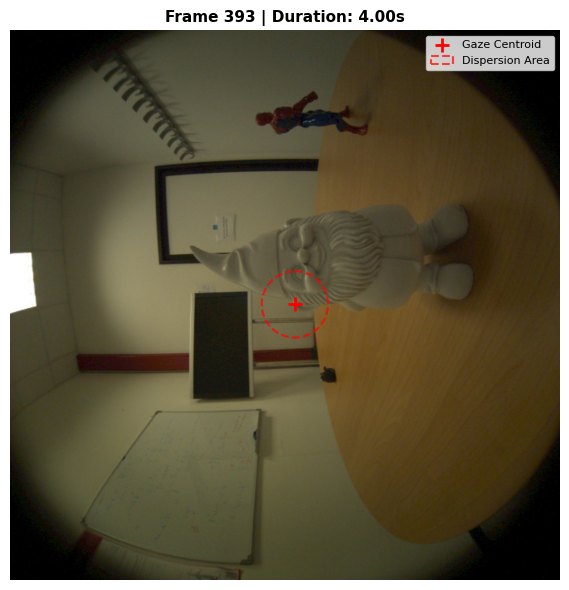


Rank #2 | Visualizing Fixation (Duration: 3.00s) ---


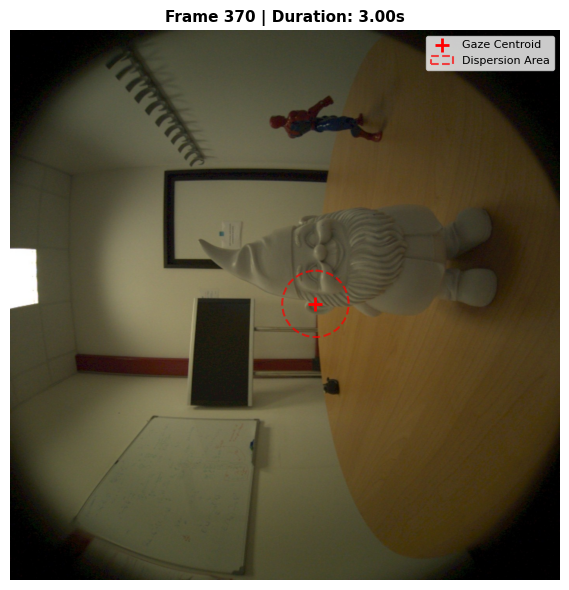


Rank #3 | Visualizing Fixation (Duration: 2.40s) ---


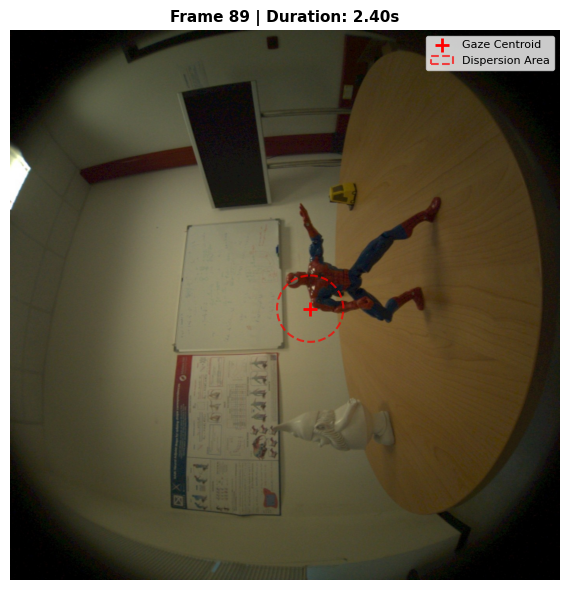


Rank #4 | Visualizing Fixation (Duration: 2.00s) ---


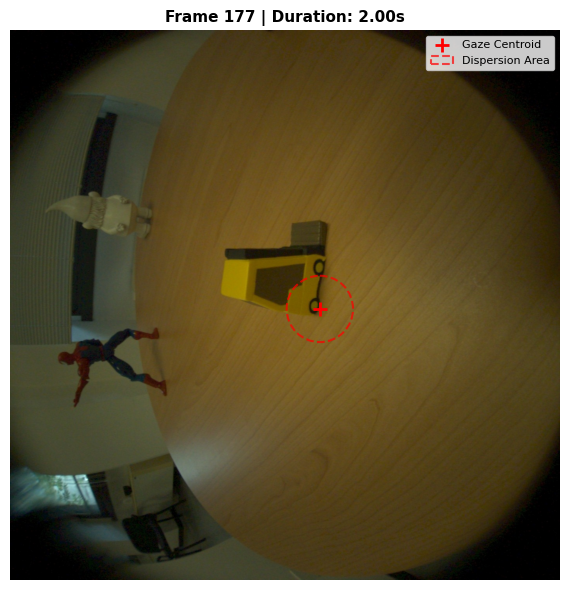


Rank #5 | Visualizing Fixation (Duration: 2.00s) ---


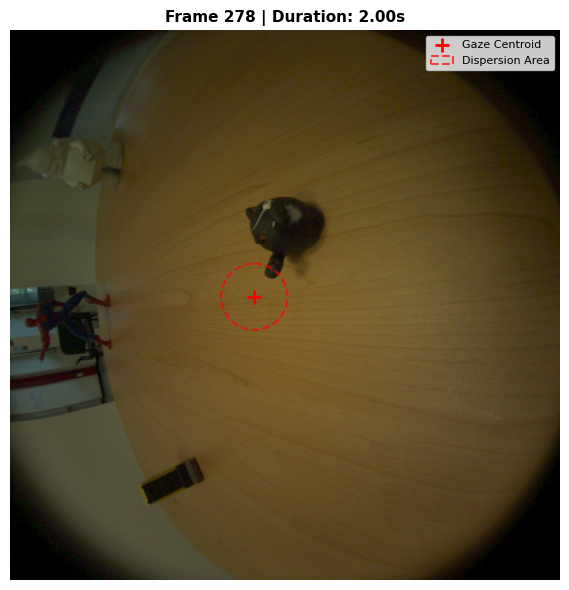

In [54]:
# Check if df_debug was populated in the previous cell
if 'df_debug' in locals() and not df_debug.empty:
    # Explicitly sort the dataframe from longest to shortest duration
    df_sorted = df_debug.sort_values(by='duration_seconds', ascending=False).reset_index(drop=True)
    
    total_fixations = len(df_sorted)
    print(f"Generating smaller visual graphs for ALL {total_fixations} detected fixations, sorted by duration...")
    
    # Iterate over every single fixation
    for i in range(total_fixations):
        row_data = df_sorted.iloc[i]
        duration = row_data['duration_seconds']
        
        print(f"\nRank #{i+1} | Visualizing Fixation (Duration: {duration:.2f}s) ---")
        
        # Plot the graph using a compact 6x6 size
        visualize_fixation(row_data, FRAMES_DIR, dispersion_radius=DEBUG_DISPERSION_PX, figsize=(6, 6))
        
else:
    print("Cannot visualize: 'df_debug' is empty or not defined. Run the previous cell first.")

### 10.4.4 Final Fixation Extraction

Based on the visual debug analysis, we set the definitive threshold for intentional observation to 1.25 seconds for this specific recording. At a sampling rate of 10 fps, this translates to roughly 13 continuous frames. 
We will now extract the final set of fixations that will serve as our active SAM2 prompts.

In [55]:
import math

FINAL_DURATION_SEC = 2
FINAL_DISPERSION_PX = 85.0
FPS = 5.0  # operating at 5 fps

# Calculate frames, rounding up to ensure strict adherence to the minimum time
FINAL_MIN_FRAMES = math.ceil(FINAL_DURATION_SEC * FPS)

print(f"Applying final thresholds: {FINAL_DURATION_SEC}s ({FINAL_MIN_FRAMES} frames @ {FPS} fps), {FINAL_DISPERSION_PX}px dispersion.")

final_fixations = detect_fixations_idt(
    alignment,
    dispersion_threshold=FINAL_DISPERSION_PX,
    min_duration_frames=FINAL_MIN_FRAMES
)

if len(final_fixations) > 0:
    df_final = pd.DataFrame(final_fixations)
    df_final['duration_seconds'] = df_final['duration_frames'] / FPS

    # Sort chronologically for the downstream pipeline
    df_final = df_final.sort_values(by='start_frame').reset_index(drop=True)

    print(f"\nExtracted {len(df_final)} definitive fixations for SAM2 processing:")
    display(df_final[['start_frame', 'end_frame', 'duration_seconds', 'centroid_x', 'centroid_y']])
else:
    print("No fixations met the final criteria.")

Applying final thresholds: 2s (10 frames @ 5.0 fps), 85.0px dispersion.

Extracted 5 definitive fixations for SAM2 processing:


,start_frame,end_frame,duration_seconds,centroid_x,centroid_y
0,84,95,2.4,768.416713,712.421157
1,173,182,2.0,793.226122,713.092739
2,274,283,2.0,625.135445,681.834480
3,363,377,3.0,781.861477,700.088725
4,384,403,4.0,729.258186,701.507366


## 10.5 SAM2 Prompt Generation

Every valid fixation detected by the I-DT algorithm will be treated as a potentially unique object and assigned a strictly incremental ID. 
We will pass all of these prompts to the SAM2 engine. 

In [56]:
def assign_incremental_ids(df_fixations):
    if df_fixations.empty:
        return df_fixations
        
    df_prompts = df_fixations.copy()
    
    # ID 0 is strictly reserved for Background in SAM2 tracking.
    # We assign IDs incrementally to each row.
    df_prompts['object_id'] = range(1, len(df_prompts) + 1)
    
    return df_prompts

# Apply assignment logic
df_all_prompts = assign_incremental_ids(df_final)

print(f"ID assignment complete. Kept all {len(df_all_prompts)} distinct prompts for SAM2.")
display(df_all_prompts[['object_id', 'start_frame', 'duration_seconds', 'centroid_x', 'centroid_y']])

ID assignment complete. Kept all 5 distinct prompts for SAM2.


,object_id,start_frame,duration_seconds,centroid_x,centroid_y
0,1,84,2.4,768.416713,712.421157
1,2,173,2.0,793.226122,713.092739
2,3,274,2.0,625.135445,681.834480
3,4,363,3.0,781.861477,700.088725
4,5,384,4.0,729.258186,701.507366


### 10.5.1 Formatting Prompts for SAM2 API

We transform our exhaustive list of fixations into the dictionary structure required by the SAM2 video predictor API. Each dictionary contains the unique `object_id`, the `init_frame_idx` where the fixation started, and the spatial coordinates for the positive point prompt (`point_labels = [1]`).

In [57]:
# Create a structured list of prompts for the SAM2 video predictor
sam2_initialization_prompts = []

# Iterate through every single fixation
for _, row in df_all_prompts.iterrows():
    
    prompt_data = {
        'object_id': int(row['object_id']),
        'init_frame_idx': int(row['start_frame']),
        'point_coords': [float(row['centroid_x']), float(row['centroid_y'])],
        'point_labels': [1] # 1 represents a positive click 
    }
    
    sam2_initialization_prompts.append(prompt_data)

print("SAM2 Initialization Prompts generated successfully:\n")
for p in sam2_initialization_prompts:
    coords = [round(c, 1) for c in p['point_coords']]
    print(f"Object_ID: {p['object_id']:02d} | Start Frame: {p['init_frame_idx']:06d} | Target Coords: {coords}")

SAM2 Initialization Prompts generated successfully:

Object_ID: 01 | Start Frame: 000084 | Target Coords: [768.4, 712.4]
Object_ID: 02 | Start Frame: 000173 | Target Coords: [793.2, 713.1]
Object_ID: 03 | Start Frame: 000274 | Target Coords: [625.1, 681.8]
Object_ID: 04 | Start Frame: 000363 | Target Coords: [781.9, 700.1]
Object_ID: 05 | Start Frame: 000384 | Target Coords: [729.3, 701.5]


## 10.6 SAM2 Inference: Multi-Run Mono-Prompt Strategy

Instead of inserting all fixation prompts into a single SAM2 session (which can cause inter-object interference during propagation), we run SAM2 **once per object**. Each run tracks a single prompt across the full video. The per-object binary masks are then merged into a unified multi-label mask at the end.

### Advantages over single-run multi-prompt:
- Each object is tracked in isolation — no cross-contamination between masks
- Failed prompts can be discarded without affecting others
- Memory footprint per run is lower

### 10.6.1 SAM2 Model Loading

In [58]:
import os
import torch
from sam2.build_sam import build_sam2_video_predictor

# SAM2 path configuration
PROJECT_ROOT = "c:/Users/Gmalv/Desktop/Scuola_Universita/AriaGen1"
CHECKPOINT_DIR = os.path.join(PROJECT_ROOT, "checkpoints")

CHECKPOINT_NAME = "sam2_hiera_small.pt"
SAM2_CHECKPOINT = os.path.join(CHECKPOINT_DIR, CHECKPOINT_NAME)
SAM2_CONFIG = os.path.join(PROJECT_ROOT, "third_party", "sam2", "sam2", "configs", "sam2", "sam2_hiera_s.yaml")

if not os.path.exists(SAM2_CHECKPOINT):
    raise FileNotFoundError(f"No model found: {SAM2_CHECKPOINT}")
if not os.path.exists(SAM2_CONFIG):
    raise FileNotFoundError(f"No configuration found: {SAM2_CONFIG}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading SAM2 model on device: {device}")

predictor = build_sam2_video_predictor(SAM2_CONFIG, SAM2_CHECKPOINT, device=device)
print("SAM2 video predictor loaded.")

Loading SAM2 model on device: cuda
SAM2 video predictor loaded.


### 10.6.2 Video State Initialization

Load the video frames into SAM2's inference state. This is done **once** — individual runs reuse the loaded video via `reset_state()` to avoid redundant I/O.

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()

# Initialize state once
inference_state = predictor.init_state(
    video_path=FRAMES_DIR,
    offload_video_to_cpu=True,
    offload_state_to_cpu=True,
)
predictor.reset_state(inference_state)

print(f"Inference state initialized on: {FRAMES_DIR}")

frame loading (JPEG): 100%|██████████| 461/461 [00:29<00:00, 15.64it/s]


Inference state initialized on: ..\data\outputs\segmentation\table_objects\frames_5fps


### 10.6.3 Per-Object Propagation Loop

For each fixation prompt, reset the tracker state, insert the single point prompt, run bidirectional propagation (forward + backward), and store the resulting binary mask per frame.

In [ ]:
import time

def run_single_prompt(predictor, inference_state, prompt, n_frames_total):
    """
    Run SAM2 forward+backward for a single object prompt.
    Returns a dict: {frame_idx: binary_mask (H, W) bool}.
    """
    obj_id = prompt['object_id']
    init_frame = prompt['init_frame_idx']

    # Reset tracking state
    predictor.reset_state(inference_state)

    # Insert the single point prompt
    _, _, _ = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=init_frame,
        obj_id=obj_id,
        points=np.array([prompt['point_coords']], dtype=np.float32),
        labels=np.array(prompt['point_labels'], dtype=np.int32),
    )

    masks = {}

    # Forward pass
    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
            idx = int(out_frame_idx)
            if idx >= init_frame:
                binary = (out_mask_logits[0, 0] > 0).detach().cpu().numpy()
                masks[idx] = binary

    # Backward pass
    with torch.inference_mode(), torch.autocast(device_type="cuda", dtype=torch.float16):
        for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(
            inference_state, start_frame_idx=init_frame, reverse=True
        ):
            idx = int(out_frame_idx)
            if idx < init_frame:
                binary = (out_mask_logits[0, 0] > 0).detach().cpu().numpy()
                masks[idx] = binary

    return masks

print("run_single_prompt() defined.")

run_single_prompt() defined.


In [61]:
# Run SAM2 independently for each prompt
per_object_masks = {}  # {object_id: {frame_idx: binary_mask}}

total_prompts = len(sam2_initialization_prompts)
print(f"Running {total_prompts} independent SAM2 sessions...\n")

for pi, prompt in enumerate(sam2_initialization_prompts):
    obj_id = prompt['object_id']
    coords = [round(c, 1) for c in prompt['point_coords']]
    print(f"[{pi+1}/{total_prompts}] Object {obj_id:02d} | frame {prompt['init_frame_idx']} | coords {coords}")

    t0 = time.time()
    masks = run_single_prompt(predictor, inference_state, prompt, n_frames_5fps)
    dt = time.time() - t0

    per_object_masks[obj_id] = masks

    n_active = sum(1 for m in masks.values() if m.any())
    print(f"  -> {len(masks)} frames processed, {n_active} with active mask ({dt:.1f}s)\n")

print(f"All {total_prompts} runs complete.")

Running 5 independent SAM2 sessions...

[1/5] Object 01 | frame 84 | coords [768.4, 712.4]


c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 85/85 [01:01<00:00,  1.39it/s]


  -> 461 frames processed, 461 with active mask (210.8s)

[2/5] Object 02 | frame 173 | coords [793.2, 713.1]


propagate in video: 100%|██████████| 174/174 [02:06<00:00,  1.37it/s]


  -> 461 frames processed, 461 with active mask (337.3s)

[3/5] Object 03 | frame 274 | coords [625.1, 681.8]


...

  -> 461 frames processed, 461 with active mask (337.4s)

[4/5] Object 04 | frame 363 | coords [781.9, 700.1]


propagate in video: 100%|██████████| 364/364 [04:26<00:00,  1.37it/s]


  -> 461 frames processed, 461 with active mask (337.7s)

[5/5] Object 05 | frame 384 | coords [729.3, 701.5]


propagate in video: 100%|██████████| 385/385 [04:42<00:00,  1.36it/s]


  -> 461 frames processed, 461 with active mask (337.6s)

All 5 runs complete.


### 10.6.4 Mask Merging & Export

Combine per-object binary masks into unified multi-label masks. When objects overlap, the higher object ID takes priority.

In [62]:
def apply_palette_and_save(frame_idx, label_mask, output_dir):
    """Save a label mask as a palettized PNG."""
    os.makedirs(output_dir, exist_ok=True)
    mask_path = os.path.join(output_dir, f"{int(frame_idx):06d}.png")

    img = Image.fromarray(label_mask, mode='P')

    palette = [
        0, 0, 0,          # 0: Background
        255, 0, 0,        # 1: Red
        0, 255, 0,        # 2: Green
        0, 100, 255,      # 3: Light Blue
        255, 255, 0,      # 4: Yellow
        255, 0, 255,      # 5: Magenta
        0, 255, 255,      # 6: Cyan
        255, 128, 0,      # 7: Orange
        128, 0, 255,      # 8: Purple
        0, 255, 128,      # 9: Light Green
    ]
    palette += [0] * (768 - len(palette))

    img.putpalette(palette)
    img.save(mask_path, compress_level=1)
    return mask_path

print("apply_palette_and_save() defined.")

apply_palette_and_save() defined.


In [63]:
# Merge all per-object masks into unified label masks
all_frame_indices = set()
for masks in per_object_masks.values():
    all_frame_indices.update(masks.keys())

print(f"Merging masks across {len(all_frame_indices)} frames for {len(per_object_masks)} objects...")

# Determine mask dimensions from the first available mask
sample_mask = next(iter(next(iter(per_object_masks.values())).values()))
h, w = sample_mask.shape

export_count = 0
for frame_idx in sorted(all_frame_indices):
    label_mask = np.zeros((h, w), dtype=np.uint8)

    # Layer objects in order (lower ID first, higher ID overwrites on overlap)
    for obj_id in sorted(per_object_masks.keys()):
        if frame_idx in per_object_masks[obj_id]:
            binary = per_object_masks[obj_id][frame_idx]
            label_mask[binary] = obj_id

    apply_palette_and_save(frame_idx, label_mask, MASKS_DIR)
    export_count += 1

print(f"\nExported {export_count} merged mask frames to: {MASKS_DIR}")

Merging masks across 461 frames for 5 objects...

Exported 461 merged mask frames to: ..\data\outputs\segmentation\table_objects\sam2\masks


## 10.7 SAM2 Single Run, Multi-Prompt

We now implement the Single Run, Multi-Prompt approach on the full video sequence. We inject every detected fixation centroid (including spatial outliers and temporal duplicates) into a single, shared SAM2 inference state as distinct objects. 

We then execute a bidirectional temporal tracking (Forward and Backward propagation) to generate masks for the entire video.


In [66]:
import os
import numpy as np

# Create the dedicated output directory
SINGLE_RUN_MASKS_DIR = os.path.join(OUT_ROOT, "mask_single_run")
os.makedirs(SINGLE_RUN_MASKS_DIR, exist_ok=True)

print("INITIALIZING SAM2 SINGLE RUN MULTI-PROMPT")

# Initialize a single shared inference state for the entire video
inference_state = predictor.init_state(video_path=FRAMES_DIR)
predictor.reset_state(inference_state)

# Inject ALL fixation points from the debug DataFrame into the state
for idx, row in df_debug.iterrows():
    obj_id = idx + 1
    
    frame_idx = int(row['start_frame'])
    
    # SAM2 requires points formatted as float32 arrays and labels as int32
    pt_coords = np.array([[row['centroid_x'], row['centroid_y']]], dtype=np.float32)
    pt_labels = np.array([1], dtype=np.int32) # 1 represents a positive prompt
    
    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=frame_idx,
        obj_id=obj_id,
        points=pt_coords,
        labels=pt_labels
    )
    print(f"Injected Prompt {obj_id:02d} at Frame {frame_idx:04d} -> (x: {row['centroid_x']:.1f}, y: {row['centroid_y']:.1f})")

INITIALIZING SAM2 SINGLE RUN MULTI-PROMPT


frame loading (JPEG): 100%|██████████| 461/461 [00:43<00:00, 10.56it/s]
c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Injected Prompt 01 at Frame 0384 -> (x: 729.3, y: 701.5)
Injected Prompt 02 at Frame 0363 -> (x: 781.9, y: 700.1)
Injected Prompt 03 at Frame 0084 -> (x: 768.4, y: 712.4)
Injected Prompt 04 at Frame 0173 -> (x: 793.2, y: 713.1)
Injected Prompt 05 at Frame 0274 -> (x: 625.1, y: 681.8)


In [69]:
from tqdm.auto import tqdm

tracked_video_masks = {}

print("\nSTARTING BIDIRECTIONAL PROPAGATION")

device_type = "cuda" if torch.cuda.is_available() else "cpu"

with torch.inference_mode(), torch.autocast(device_type=device_type, dtype=torch.bfloat16):
    
    # FORWARD PROPAGATION
    print("Propagating FORWARD through the video frames...")
    for out_frame_idx, out_obj_ids, out_mask_logits in tqdm(predictor.propagate_in_video(inference_state)):
        if out_frame_idx not in tracked_video_masks:
            tracked_video_masks[out_frame_idx] = {}
        
        for i, obj_id in enumerate(out_obj_ids):
            binary_mask = (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()
            tracked_video_masks[out_frame_idx][obj_id] = binary_mask

    # BACKWARD PROPAGATION
    print("Propagating BACKWARD through the video frames...")
    for out_frame_idx, out_obj_ids, out_mask_logits in tqdm(predictor.propagate_in_video(inference_state, reverse=True)):
        if out_frame_idx not in tracked_video_masks:
            tracked_video_masks[out_frame_idx] = {}
            
        for i, obj_id in enumerate(out_obj_ids):
            binary_mask = (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()
            tracked_video_masks[out_frame_idx][obj_id] = binary_mask

print("\nMERGING AND EXPORTING MASKS")

h, w = binary_mask.shape 
export_count = 0

for frame_idx in tqdm(sorted(tracked_video_masks.keys()), desc="Saving to mask_single_run"):
    # Initialize a blank canvas (0 = background)
    merged_mask = np.zeros((h, w), dtype=np.uint8)
    
    frame_data = tracked_video_masks[frame_idx]
    
    # Layer objects onto the canvas
    for obj_id in sorted(frame_data.keys()):
        merged_mask[frame_data[obj_id]] = obj_id
        
    out_img = Image.fromarray(merged_mask, mode='P')
    out_filename = os.path.join(SINGLE_RUN_MASKS_DIR, f"{frame_idx:06d}.png")
    out_img.save(out_filename)
    export_count += 1

print(f"\nExtraction Complete! {export_count} frames exported to '{SINGLE_RUN_MASKS_DIR}'.")

propagate in video:   3%|▎         | 11/377 [00:35<19:37,  3.22s/it]


STARTING BIDIRECTIONAL PROPAGATION
Propagating FORWARD through the video frames...


0it [00:00, ?it/s]

c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\Gmalv\Desktop\Scuola_Universita\AriaGen1\venv\Lib\site-packages\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 377/377 [12:40<00:00,  2.02s/it]

Propagating BACKWARD through the video frames...


0it [00:00, ?it/s]

propagate in video: 100%|██████████| 85/85 [03:43<00:00,  2.64s/it]


MERGING AND EXPORTING MASKS


Saving to mask_single_run:   0%|          | 0/461 [00:00<?, ?it/s]


Extraction Complete! 461 frames exported to '..\data\outputs\segmentation\table_objects\mask_single_run'.


In [75]:
import os
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

SINGLE_RUN_MASKS_DIR = os.path.join(OUT_ROOT, "sam2", "mask_single_run")

# La tua palette esatta (0=Background, 1=Rosso, 2=Verde...)
palette = [
    0, 0, 0,          # 0: Background
    255, 0, 0,        # 1: Red
    0, 255, 0,        # 2: Green
    0, 100, 255,      # 3: Light Blue
    255, 255, 0,      # 4: Yellow
    255, 0, 255,      # 5: Magenta
    0, 255, 255,      # 6: Cyan
    255, 128, 0,      # 7: Orange
    128, 0, 255,      # 8: Purple
    0, 255, 128,      # 9: Light Green
]
full_palette = palette + [0] * (768 - len(palette))

# Prendi le dimensioni dal primo frame disponibile
sample_mask = next(iter(next(iter(tracked_video_masks.values())).values()))
h, w = sample_mask.shape

print("Esportazione maschere: assegnazione diretta ID -> Colore...")

for frame_idx in tqdm(sorted(tracked_video_masks.keys()), desc="Salvando maschere"):
    # Tela nera (valore 0)
    merged_mask = np.zeros((h, w), dtype=np.uint8)
    frame_data = tracked_video_masks[frame_idx]
    
    # Assegnazione "normale": il pixel prende esattamente il valore del suo ID
    # Li cicliamo in ordine numerico (1, 2, 3...)
    for obj_id in sorted(frame_data.keys()):
        merged_mask[frame_data[obj_id]] = obj_id
        
    # Creazione immagine e assegnazione diretta della palette
    out_img = Image.fromarray(merged_mask, mode='P')
    out_img.putpalette(full_palette)
    
    out_filename = os.path.join(SINGLE_RUN_MASKS_DIR, f"{frame_idx:06d}.png")
    out_img.save(out_filename)

print("Fatto. Maschere salvate con i colori corretti associati agli ID.")

Esportazione maschere: assegnazione diretta ID -> Colore...


Salvando maschere:   0%|          | 0/461 [00:00<?, ?it/s]

Fatto. Maschere salvate con i colori corretti associati agli ID.
